In [2]:
# 1. OpenCV 설치 (cv2 모듈)
!pip install opencv-python

# 2. dlib 설치를 위한 cmake 설치
!pip install cmake

# 3. 얼굴 검출을 위한 dlib 설치 
!pip install dlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 41.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 50.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.4 MB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dlib: filename=dlib-20.0.1-cp312-cp312-linux_x86_64.whl size=4160911 sha256=ec2cb8b3c31ba4a0ebb08d307124c64ebb9c740891d2e67120c2d08c7e44b401
  Stored in directory: /home/jovyan/.cache/pip/wheels/0d/a3/e4/89c1a393cbb86433554f89465e1f2b4c647bca9f256b454b62
Successfully built dlib


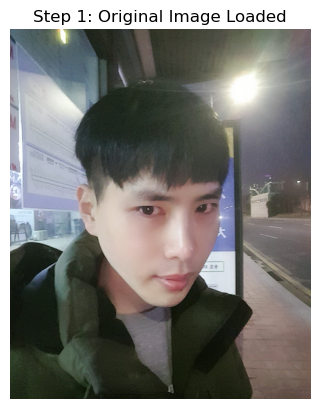

In [116]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/image.jpg')
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

# OpenCV는 왜 BGR인가? 
# 초기 카메라 제조사들이 BGR 방식을 선호했기 때문입니다. 
# 현대의 데이터 분석(RGB)과는 반대라 늘 cvtColor 과정을 거쳐야 하는 번거로움이 있죠.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Step 1: Original Image Loaded")
plt.axis('off')
plt.show()

찾은 얼굴 개수: 1


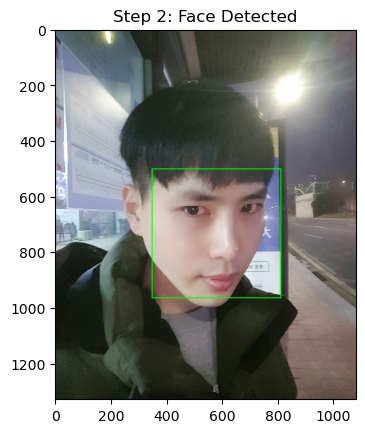

In [117]:
# dlib의 HOG 기반 얼굴 검출기 초기화
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출 (1은 이미지 피라미드 단계 - 작게 찍힌 얼굴도 키워서 찾겠다는 뜻)
dlib_rects = detector_hog(img_rgb, 1) 

print(f"찾은 얼굴 개수: {len(dlib_rects)}")

for dlib_rect in dlib_rects:
    # 사각형의 좌표 추출
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    # 도화지(img_show)에 초록색 사각형 그리기
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title("Step 2: Face Detected")
plt.show()

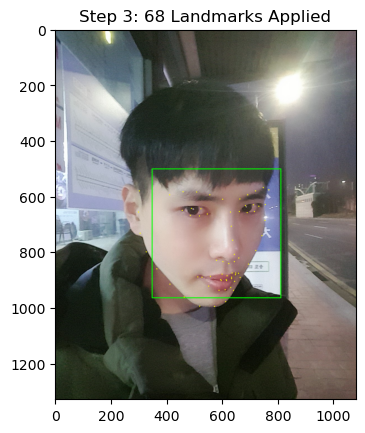

In [6]:
# 랜드마크 모델 로드
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    # 점의 좌표를 (x, y) 리스트로 변환
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

# 도화지에 68개 점 그리기 (노란색 점)
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title("Step 3: 68 Landmarks Applied")
plt.show()

In [7]:
#  사진
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 코 끝(index 30)의 x, y 좌표
    x_nose, y_nose = landmark[30]
    
    # 스티커 크기를 얼굴 사각형 너비와 똑같이 맞춥니다.
    w = h = dlib_rect.width()
    
    # [좌표 계산] 
    # x: 코 끝의 중앙에 스티커 중심이 오도록 (x - w/2)
    # y: 코 끝 높이에서 얼굴 높이의 절반만큼 위로 (y - h/2) 
    # 그 후 스티커 자체의 높이만큼 다시 위로 빼줘야 머리 위로 갑니다.
    refined_x = x_nose - w // 2
    refined_y = y_nose - h # 코 끝에서 스티커 높이만큼 위로
    
    print(f"스티커 시작점: ({refined_x}, {refined_y}), 크기: ({w}, {h})")

스티커 시작점: (412, 346), 크기: (463, 463)


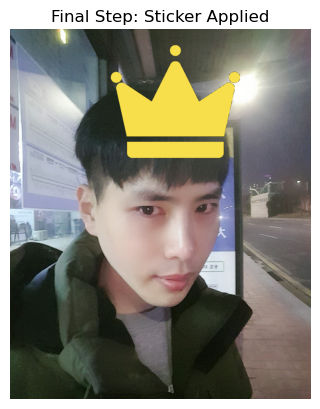

In [118]:
# 스티커 이미지 불러오기
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))

# [예외 처리] 만약 머리 위가 잘린 사진이라 y가 음수라면?
if refined_y < 0:
    # 밖으로 나간 만큼 스티커 이미지를 잘라냅니다.
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0

# 최종 원본 이미지(img_bgr)에 덮어씌우기
# ROI: Region of Interest (스티커가 붙을 영역만 따오기)
sticker_area = img_bgr[refined_y:refined_y + img_sticker.shape[0], 
                       refined_x:refined_x + img_sticker.shape[1]]

# [블렌딩] 스티커에서 색깔이 있는 부분(0이 아닌 부분)만 원본에 덮어씀
img_bgr[refined_y:refined_y + img_sticker.shape[0], 
        refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker==0, sticker_area, img_sticker).astype(np.uint8)

# 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Final Step: Sticker Applied")
plt.axis('off')
plt.show()

In [119]:
# 수정된 Step 4: 더 정교한 좌표 계산
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 1. 가로 중심점은 그대로 코(index 30)를 기준으로 합니다.
    x_nose = landmark[30][0]
    
    # 2. 스티커 크기 설정
    w = h = dlib_rect.width()
    
    # 3. [핵심 수정] y 좌표 계산
    # dlib_rect.top()은 얼굴을 감싼 사각형의 맨 윗부분(이마/머리카락 경계)입니다.
    # 왕관의 '바닥'이 이마에 닿아야 하므로, 
    # 시작점(상단 좌표)은 '이마 좌표 - 왕관 높이'가 되어야 합니다.
    refined_x = x_nose - w // 2
    refined_y = dlib_rect.top() - h  # 얼굴 박스 위쪽 끝에서 왕관 높이만큼 더 위로!

    # 만약 너무 위로 떴다면, 약간 아래로 내릴 수 있습니다 (예: + 20)
    # refined_y = dlib_rect.top() - h + 20 

    print(f"수정된 시작점: ({refined_x}, {refined_y})")

수정된 시작점: (412, 39)


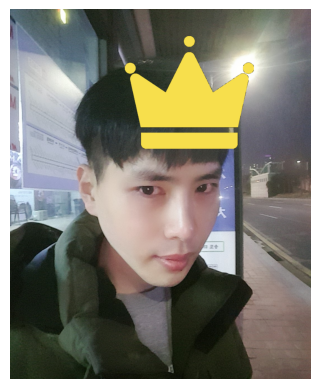

In [120]:
# ==============================================================================
# [수정된 Step 5] 도화지 초기화 후 합성
# ==============================================================================

# 1. 중요: 원본 이미지를 다시 불러옵니다.
img_bgr = cv2.imread(my_image_path) 

# 2. 스티커 이미지 준비 (좌표 계산은 위에서 한 그대로 사용)
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 예외 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

# 4. 합성 영역(ROI) 설정
sticker_area = img_bgr[refined_y:refined_y + img_sticker.shape[0], 
                       refined_x:refined_x + img_sticker.shape[1]]

# 5. np.where로 투명 배경 제외하고 합성
img_bgr[refined_y:refined_y + img_sticker.shape[0], 
        refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker==0, sticker_area, img_sticker).astype(np.uint8)

# 6. 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [121]:
# 수정된 Step 4: 왼쪽으로 이동하기
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x_nose = landmark[30][0]
    w = h = dlib_rect.width()
    
    # [기본] x_nose - w // 2 는 정확히 가운데 정렬입니다.
    # [수정] 뒤에 - 50을 붙여서 왼쪽으로 50픽셀 이동시킵니다.
    shift_left = 50 # 이동하고 싶은 만큼의 픽셀 값
    refined_x = x_nose - w // 2 - shift_left
    
    # y 좌표는 이전과 동일하게 유지하거나 필요시 수정
    refined_y = dlib_rect.top() - h 

    print(f"왼쪽으로 이동된 시작점: ({refined_x}, {refined_y})")

왼쪽으로 이동된 시작점: (362, 39)


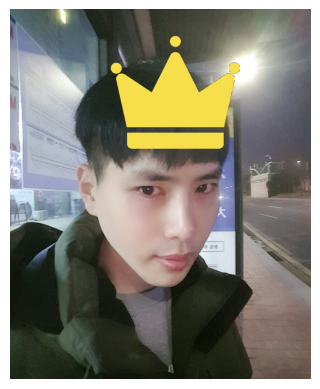

In [122]:
# ==============================================================================
# [수정된 Step 5] 도화지 초기화 후 합성
# ==============================================================================

# 1. 중요: 원본 이미지를 다시 불러옵니다.
img_bgr = cv2.imread(my_image_path) 

# 2. 스티커 이미지 준비 (좌표 계산은 위에서 한 그대로 사용)
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 예외 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

# 4. 합성 영역(ROI) 설정
sticker_area = img_bgr[refined_y:refined_y + img_sticker.shape[0], 
                       refined_x:refined_x + img_sticker.shape[1]]

# 5. np.where로 투명 배경 제외하고 합성
img_bgr[refined_y:refined_y + img_sticker.shape[0], 
        refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker==0, sticker_area, img_sticker).astype(np.uint8)

# 6. 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [123]:
# 수정된 Step 4: y축 이동하기
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x_nose = landmark[30][0]
    w = h = dlib_rect.width()
    
    # x 좌표는 이전 설정 유지 (왼쪽으로 50 옮긴 상태라면)
    refined_x = x_nose - w // 2 - 50 
    
    # [y축 이동] 
    # 기본: dlib_rect.top() - h (얼굴 박스 바로 위)
    shift_y = 30 # 이동하고 싶은 픽셀 값
    
    # 위로 더 올리고 싶을 때
    refined_y = dlib_rect.top() - h - shift_y 
    
    # 만약 아래로 내리고 싶다면?
    # refined_y = dlib_rect.top() - h + shift_y

    print(f"y축 이동된 시작점: ({refined_x}, {refined_y})")

y축 이동된 시작점: (362, 9)


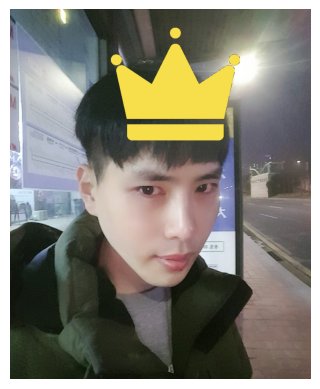

In [124]:
# ==============================================================================
# [수정된 Step 5] 도화지 초기화 후 합성
# ==============================================================================

# 1. 중요: 원본 이미지를 다시 불러옵니다.
img_bgr = cv2.imread(my_image_path) 

# 2. 스티커 이미지 준비 (좌표 계산은 위에서 한 그대로 사용)
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 예외 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

# 4. 합성 영역(ROI) 설정
sticker_area = img_bgr[refined_y:refined_y + img_sticker.shape[0], 
                       refined_x:refined_x + img_sticker.shape[1]]

# 5. np.where로 투명 배경 제외하고 합성
img_bgr[refined_y:refined_y + img_sticker.shape[0], 
        refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker==0, sticker_area, img_sticker).astype(np.uint8)

# 6. 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [125]:
# 수정된 Step 4: y축 이동하기
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x_nose = landmark[30][0]
    w = h = dlib_rect.width()
    
    # x 좌표는 이전 설정 유지 (왼쪽으로 50 옮긴 상태라면)
    refined_x = x_nose - w // 2 - 50 
    
    # [y축 이동] 
    # 기본: dlib_rect.top() - h (얼굴 박스 바로 위)
    shift_y = 70 # 이동하고 싶은 픽셀 값
    
    # 위로 더 올리고 싶을 때
    refined_y = dlib_rect.top() - h - shift_y 
    
    # 만약 아래로 내리고 싶다면?
    # refined_y = dlib_rect.top() - h + shift_y

    print(f"y축 이동된 시작점: ({refined_x}, {refined_y})")

y축 이동된 시작점: (362, -31)


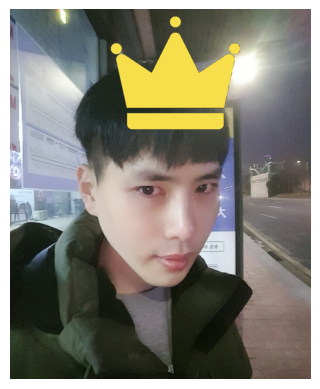

In [126]:
# ==============================================================================
# [수정된 Step 5] 도화지 초기화 후 합성
# ==============================================================================

# 1. 중요: 원본 이미지를 다시 불러옵니다.
img_bgr = cv2.imread(my_image_path) 

# 2. 스티커 이미지 준비 (좌표 계산은 위에서 한 그대로 사용)
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 예외 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

# 4. 합성 영역(ROI) 설정
sticker_area = img_bgr[refined_y:refined_y + img_sticker.shape[0], 
                       refined_x:refined_x + img_sticker.shape[1]]

# 5. np.where로 투명 배경 제외하고 합성
img_bgr[refined_y:refined_y + img_sticker.shape[0], 
        refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker==0, sticker_area, img_sticker).astype(np.uint8)

# 6. 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [127]:
# 수정된 Step 4: y축 이동하기
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x_nose = landmark[30][0]
    w = h = dlib_rect.width()
    
    # x 좌표는 이전 설정 유지 (왼쪽으로 50 옮긴 상태라면)
    refined_x = x_nose - w // 2 - 50 
    
    # [y축 이동] 
    # 기본: dlib_rect.top() - h (얼굴 박스 바로 위)
    shift_y = 120 # 이동하고 싶은 픽셀 값
    
    # 위로 더 올리고 싶을 때
    refined_y = dlib_rect.top() - h - shift_y 
    
    # 만약 아래로 내리고 싶다면?
    # refined_y = dlib_rect.top() - h + shift_y

    print(f"y축 이동된 시작점: ({refined_x}, {refined_y})")

y축 이동된 시작점: (362, -81)


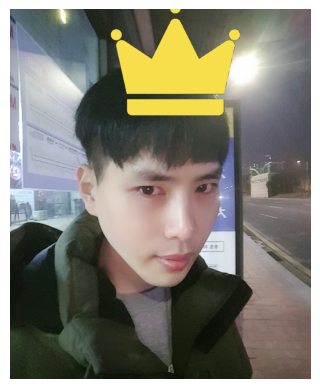

In [128]:
# ==============================================================================
# [수정된 Step 5] 도화지 초기화 후 합성
# ==============================================================================

# 1. 중요: 원본 이미지를 다시 불러옵니다.
img_bgr = cv2.imread(my_image_path) 

# 2. 스티커 이미지 준비 (좌표 계산은 위에서 한 그대로 사용)
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))

# 3. 예외 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

# 4. 합성 영역(ROI) 설정
sticker_area = img_bgr[refined_y:refined_y + img_sticker.shape[0], 
                       refined_x:refined_x + img_sticker.shape[1]]

# 5. np.where로 투명 배경 제외하고 합성
img_bgr[refined_y:refined_y + img_sticker.shape[0], 
        refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker==0, sticker_area, img_sticker).astype(np.uint8)

# 6. 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

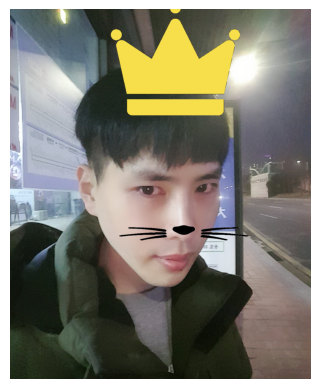

In [129]:
# ==============================================================================
# [단계 1] 수염 전용 좌표 새로 계산 (왕관 위치랑 섞이지 않게!)
# ==============================================================================
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 1. 기준점: 코 끝 (Landmark 30) - 수염은 코에 붙어야 하니까요!
    x_nose, y_nose = landmark[30]

    # 2. 수염 전용 크기 (왕관이랑은 별개로 설정)
    w_face = dlib_rect.width()
    h_face = dlib_rect.height()
    
    whis_w = int(w_face * 1.0) # 얼굴 너비만큼
    whis_h = int(h_face * 0.5) # 높이는 얼굴의 절반
    
    # 3. 수염 전용 시작점 계산 (기존 refined_y를 덮어씁니다)
    # 수염의 정중앙이 코 끝에 오도록 계산
    shift_left = 20
    shift_top = 5
    whis_x = x_nose - (whis_w // 2) - shift_left
    whis_y = y_nose - whis_h // 2 - shift_top # <--- 여기가 왕관 위치랑 달라지는 핵심!

# ==============================================================================
# [단계 2] 수염 이미지 로드 및 마스크 준비
# ==============================================================================
img_whis = cv2.imread(whiskers_path)
img_whis = cv2.resize(img_whis, (whis_w, whis_h))

# 흰 배경 제거용 마스크 생성
img_whis_gray = cv2.cvtColor(img_whis, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img_whis_gray, 230, 255, cv2.THRESH_BINARY_INV)

# ==============================================================================
# [단계 3] 수염 전용 경계면 처리 (왕관 때 썼던 logic 재활용)
# ==============================================================================
# 여기서 변수는 whis_x, whis_y를 써야 왕관 위치를 안 건드립니다.
if whis_x < 0:
    img_whis = img_whis[:, -whis_x:]
    mask = mask[:, -whis_x:]
    whis_x = 0
if whis_x + img_whis.shape[1] > img_bgr.shape[1]:
    diff = (whis_x + img_whis.shape[1]) - img_bgr.shape[1]
    img_whis = img_whis[:, :-diff]
    mask = mask[:, :-diff]
if whis_y < 0:
    img_whis = img_whis[-whis_y:, :]
    mask = mask[-whis_y:, :]
    whis_y = 0
if whis_y + img_whis.shape[0] > img_bgr.shape[0]:
    diff = (whis_y + img_whis.shape[0]) - img_bgr.shape[0]
    img_whis = img_whis[:-diff, :]
    mask = mask[:-diff]

# ==============================================================================
# [단계 4] 합성 (왕관이 이미 있는 img_bgr 위에 덧칠!)
# ==============================================================================
# 주의: 이 시점에서 img_bgr은 이미 왕관이 그려진 상태여야 합니다.
# 만약 왕관이 사라졌다면, 이 셀 바로 위에서 왕관 그리는 코드를 먼저 한 번 더 실행하세요.

roi = img_bgr[whis_y:whis_y + img_whis.shape[0], 
              whis_x:whis_x + img_whis.shape[1]]

# 마스크가 있는(검은 수염 부분)만 픽셀을 교체
for c in range(3):
    roi[:, :, c] = np.where(mask > 0, img_whis[:, :, c], roi[:, :, c])

# 결과 덮어쓰기
img_bgr[whis_y:whis_y + img_whis.shape[0], 
        whis_x:whis_x + img_whis.shape[1]] = roi

# 최종 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

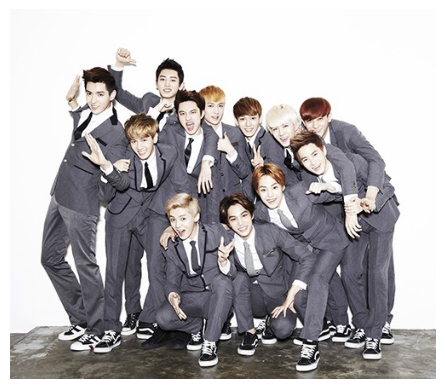

In [130]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/test1.jpg')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

찾은 얼굴 개수: 7


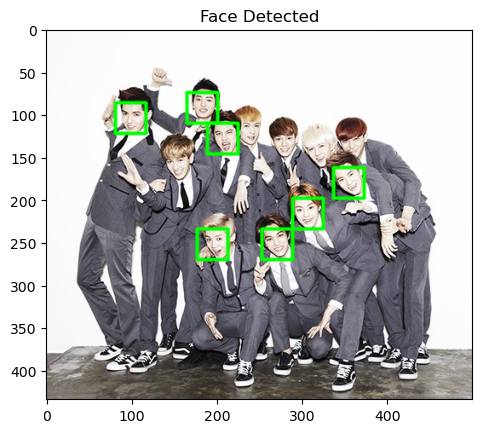

In [133]:
# dlib의 HOG 기반 얼굴 검출기 초기화
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출 (1은 이미지 피라미드 단계 - 작게 찍힌 얼굴도 키워서 찾겠다는 뜻)
dlib_rects = detector_hog(img_rgb, 1) 

print(f"찾은 얼굴 개수: {len(dlib_rects)}")

for dlib_rect in dlib_rects:
    # 사각형의 좌표 추출
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    # 도화지(img_show)에 초록색 사각형 그리기
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title("Face Detected")
plt.show()

  - 사람이 겹쳐 있거나 머리카락 등으로 눈썹이 가려지면 AI가 얼굴을 아예 못 찾는 현상 발생.
  - 실험 사진에서 10명 중 7명만 성공했는데, 이들의 공통점은 눈썹이 아주 확연하게 드러나 있었다는 것.
  - dlib HOG 알고리즘은 눈썹처럼 명암 차이가 확실한 곳을 얼굴의 핵심 힌트로 쓰는 것 같음. 
  - 눈썹이 가려지는 순간 AI는 "이건 얼굴이 아니다"라고 판단해버릴 정도로 영향이 큰 것 같음.
  - 혹시나 하는 마음에 랜드마크를 돌려보기로 함.

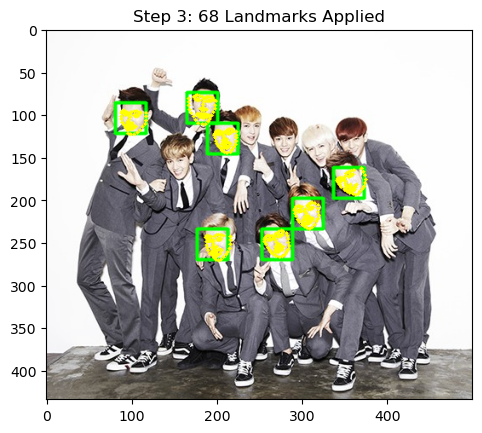

In [134]:
# 랜드마크 모델 로드
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    # 점의 좌표를 (x, y) 리스트로 변환
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

# 도화지에 68개 점 그리기 (노란색 점)
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title("Step 3: 68 Landmarks Applied")
plt.show()

  - 역시나 AI가 '얼굴'이라고 인식해서 사각형을 그린 사람한테만 Landmark가 찍힘.
  - 얼굴 검출(Detection)에 성공해야만 랜드마크 추출이 가능함. 
  - 측면 사진에서 점이 안 찍힌다면, 그건 점 찍는 모델의 문제라기보다 앞 단계인 '얼굴 찾기'에서 이미 실패했기 때문임.

In [135]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/test2.PNG')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

[ WARN:0@6559.885] global loadsave.cpp:278 findDecoder imread_('/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/test2.png'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'copy'

  - 경로 설정은 맞는데 파일을 못 읽길래 확인해보니, 확장자가 .png가 아닌 .PNG였음.
  - 윈도우와 달리 우리가 쓰는 리눅스 서버 환경은 대소문자를 완전히 다른 파일로 인식함. 
  - 코딩할 때 파일명과 확장자 대소문자를 100% 일치시켜야 한다는 교훈을 얻음.

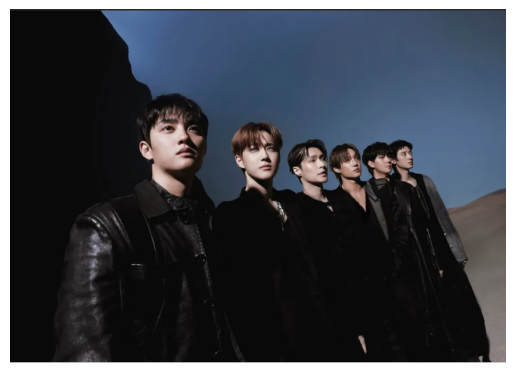

In [136]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/test2.PNG')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

찾은 얼굴 개수: 3


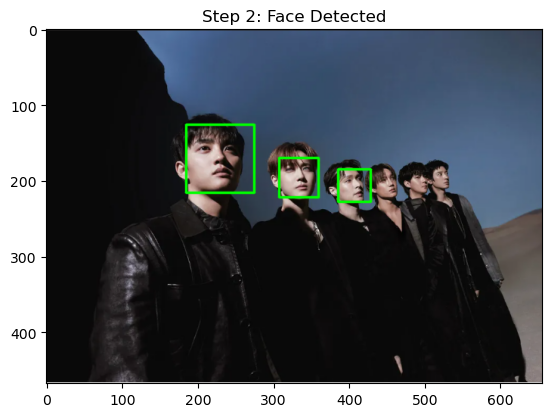

In [137]:
# dlib의 HOG 기반 얼굴 검출기 초기화
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출 (1은 이미지 피라미드 단계 - 작게 찍힌 얼굴도 키워서 찾겠다는 뜻)
dlib_rects = detector_hog(img_rgb, 1) 

print(f"찾은 얼굴 개수: {len(dlib_rects)}")

for dlib_rect in dlib_rects:
    # 사각형의 좌표 추출
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    # 도화지(img_show)에 초록색 사각형 그리기
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title("Step 2: Face Detected")
plt.show()

- 거리가 멀거나 얼굴이 옆으로 돌아갈수록(Profile) 감지 성공률이 팍팍 떨어짐.
- 어떤 사람은 눈썹이 다 보이는데도 거리가 멀고 옆모습이라는 이유로 검출되지 않음.
- '원거리 + 측면 각도 + 가림 현상'이 겹치면 AI는 거의 장님이 됨. 
- dlib HOG 모델은 정면 근접 샷에만 강하다는 것을 확인.
- 혹시나 명암에 따른 차이도 있을까라는 의문이 발생

- 명암 차이에 예민하다면, 혹시 인종(피부톤)에 따라서도 검출률이 달라지지 않을까 하는 의문이 생김.
- 이목구비가 뚜렷하게 묘사된 사람 위주로만 잘 잡히는 경향이 있음. 
- 만약 피부색이 배경과 비슷해서 명암 차이가 안 난다면 특정 인종을 못 찾을 수도 있음. 
- 이건 단순한 버그를 넘어 AI 윤리나 차별 문제로 이어질 수 있는 중요한 포인트라고 생각함.

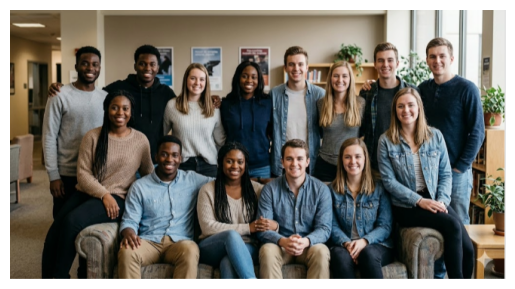

In [141]:
# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/test3.png')
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

찾은 얼굴 개수: 8


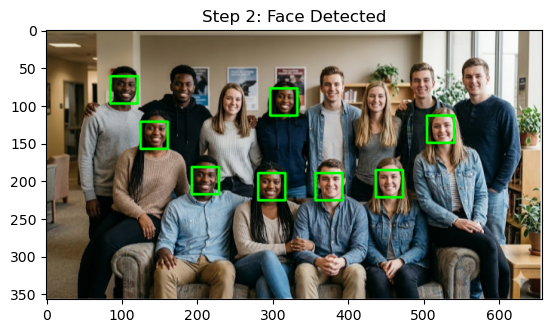

In [142]:
# dlib의 HOG 기반 얼굴 검출기 초기화
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출 (1은 이미지 피라미드 단계 - 작게 찍힌 얼굴도 키워서 찾겠다는 뜻)
dlib_rects = detector_hog(img_rgb, 1) 

print(f"찾은 얼굴 개수: {len(dlib_rects)}")

for dlib_rect in dlib_rects:
    # 사각형의 좌표 추출
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    # 도화지(img_show)에 초록색 사각형 그리기
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title("Step 2: Face Detected")
plt.show()

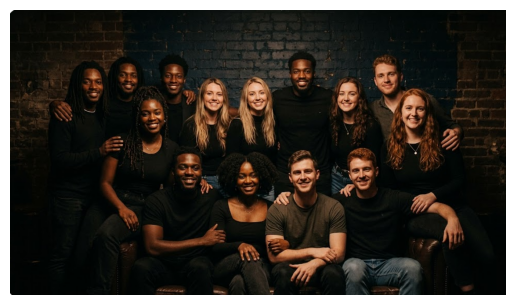

In [143]:
# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/test4.png')
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

찾은 얼굴 개수: 14


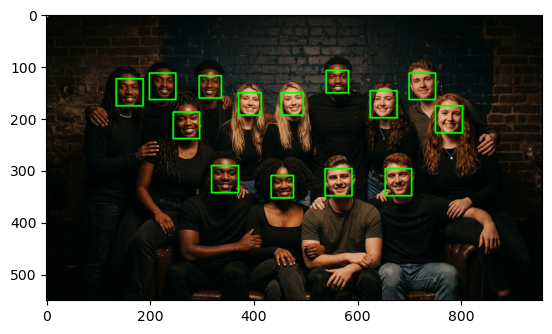

In [144]:
# dlib의 HOG 기반 얼굴 검출기 초기화
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출 (1은 이미지 피라미드 단계 - 작게 찍힌 얼굴도 키워서 찾겠다는 뜻)
dlib_rects = detector_hog(img_rgb, 1) 

print(f"찾은 얼굴 개수: {len(dlib_rects)}")

for dlib_rect in dlib_rects:
    # 사각형의 좌표 추출
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    # 도화지(img_show)에 초록색 사각형 그리기
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

- 너무 이목구비가 뚜렷해서 감지되었을 가능성을 염두해두고 조금 더 어둡게 해서 시도해보기로 한다.

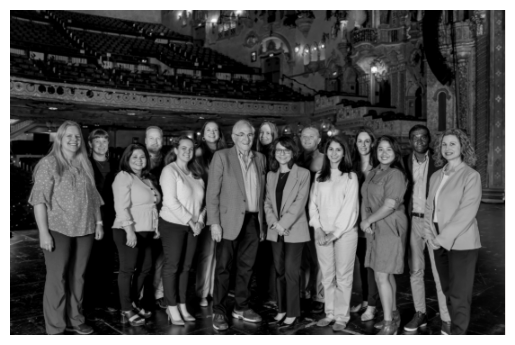

In [151]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

# 실제 경로를 변수에 담습니다.
home_dir = os.getenv('HOME')
# 경로 (image.jpg)
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/test5.PNG')
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# [이미지 로드]
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy() # 출력용 복사본 (랜드마크를 그릴 도화지)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

찾은 얼굴 개수: 0


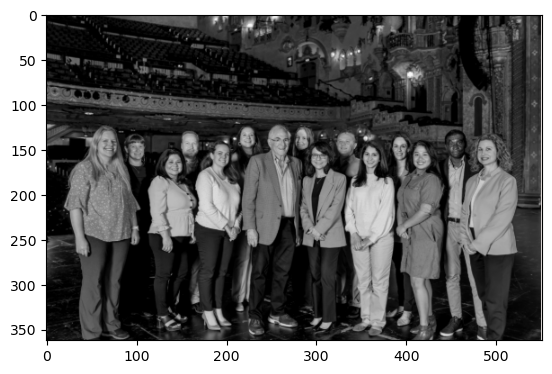

In [152]:
# dlib의 HOG 기반 얼굴 검출기 초기화
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출 (1은 이미지 피라미드 단계 - 작게 찍힌 얼굴도 키워서 찾겠다는 뜻)
dlib_rects = detector_hog(img_rgb, 1) 

print(f"찾은 얼굴 개수: {len(dlib_rects)}")

for dlib_rect in dlib_rects:
    # 사각형의 좌표 추출
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    # 도화지(img_show)에 초록색 사각형 그리기
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
  - 인종별 공정성 테스트를 위해 흑인과 백인이 섞인 사진을 구글링했지만, 적당한 실사 이미지를 찾기 어려워 AI(Imagen3)로 생성함.
  - 그런데 AI가 만든 사진은 배경이 어둡거나 밝아도 인물의 경계선(구분선)을 수학적으로 너무 뚜렷하게 그려주는 경향이 있어, 모델이 얼굴을 찾기에 너무 쉬운 조건이 됨.
  - 더 어려운 환경을 찾기 위해 계속 시도하던 중, 오히려 실제 흑백 사진(Grayscale)에서 얼굴을 제대로 구별하지 못하는 의외의 문제점을 발견함.
  - AI 생성 이미지는 픽셀 데이터가 너무 깨끗해서 HOG가 무조건 성공하는 데이터였음.
  - 반면 흑백 사진은 색상 정보가 완전히 제거된 상태에서 얼굴의 입체감이나 미세한 명암 대비가 뭉개지는 경우가 많음.
  - 색깔이 빠진 상태에서 피부톤과 배경이 비슷한 명도를 가질 때 HOG가 얼굴 패턴을 놓치는 현상을 보임으로써, 모델의 진짜 약점은 '낮은 명암 대비'라는 것을 다시 한번 확인함.

# 이번 실험을 통해 알 수 있었던 점은, 이 AI가 특정 인종을 차별한다기보다 배경과 얼굴이 얼마나 뚜렷하게 차이 나는지 즉 대비에 너무 예민하다는 것입니다.
# 조명이나 주변 환경이 조금만 바뀌어도 얼굴을 잘 못 찾는 단점이 있기 때문에, 
# 단순히 밝기 차이만 계산하는 게 아니라 진짜 사람처럼 얼굴의 특징을 똑똑하게 찾아내는 딥러닝 모델로 바꾸는 것이 꼭 필요합니다.